Data Shape: (330, 2)

DBSCAN Results:
Clusters found: 3
Anomalies detected: 30


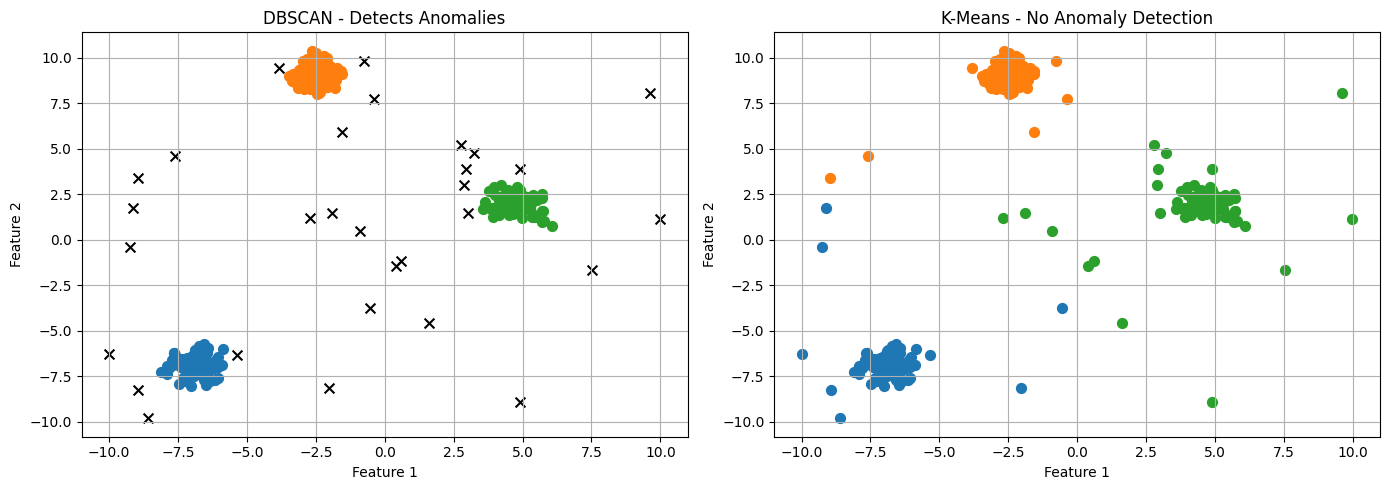

In [1]:
"""
Assignment 2: DBSCAN
Anomaly Detection
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs

# Generate network traffic data
np.random.seed(42)
normal_data, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.5)
anomalies = np.random.uniform(low=-10, high=10, size=(30, 2))
X = np.vstack([normal_data, anomalies])

print("Data Shape:", X.shape)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Results:")
print(f"Clusters found: {n_clusters}")
print(f"Anomalies detected: {n_noise}")

# K-Means for comparison
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# DBSCAN plot
for label in set(dbscan_labels):
    if label == -1:
        col = 'black'
        marker = 'x'
    else:
        col = plt.cm.tab10(label)
        marker = 'o'
    
    mask = dbscan_labels == label
    ax1.scatter(X[mask, 0], X[mask, 1], c=[col], marker=marker, s=50)

ax1.set_title('DBSCAN - Detects Anomalies')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True)

# K-Means plot
for label in range(3):
    mask = kmeans_labels == label
    ax2.scatter(X[mask, 0], X[mask, 1], s=50)

ax2.set_title('K-Means - No Anomaly Detection')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True)

plt.tight_layout()
plt.savefig('assignment2_comparison.png')